# HW2 : Cross-Validation and  Regularization

### Configuration and imports


In [27]:
import os
import numpy as np
import pandas as pd
 
import sklearn.preprocessing

import sklearn.pipeline
import sklearn.linear_model
import sklearn.metrics
import sklearn.model_selection

In [28]:
from matplotlib import pyplot as plt

import seaborn as sns
#This sets the default style for all figures. 
sns.set('notebook', font_scale=1.25, style='whitegrid')

You may need to adjust your data directory to point towards the auto data. Please do not adjust the random seed for the version of your results you turn in.  

In [29]:
SEED = 12345 

DATA_DIR = 'data_auto/'

## Helper Functions

Here we provide some functions you may find useful for your analysis. You are not **required** to use these helper functions, but you may find them useful.

### Data Loading 

In [30]:
def load_2d_arr_from_csv(fname, include_header=False):
    x = np.loadtxt(os.path.join(DATA_DIR, fname), delimiter=',', skiprows=1)
    assert x.ndim == 2
    if include_header:
        header_cols = np.loadtxt(os.path.join(DATA_DIR, fname), delimiter=',', dtype=str)[0].tolist()
        return x, header_cols
    else:
        return x
    
def load_1d_arr_from_csv(fname):
    x = np.loadtxt(os.path.join(DATA_DIR, fname), delimiter=',', skiprows=1)
    if x.ndim == 1:
        return x
    else:
        raise ValueError("Not 1d")

These functions can then be used as follows.

In [31]:
x_tr_MF, xcolnames_F = load_2d_arr_from_csv('x_train.csv', include_header=True)
x_va_NF = load_2d_arr_from_csv('x_valid.csv')
x_te_PF = load_2d_arr_from_csv('x_test.csv')

y_tr_M = load_1d_arr_from_csv('y_train.csv')
y_va_N = load_1d_arr_from_csv('y_valid.csv')
y_te_P = load_1d_arr_from_csv('y_test.csv')

print(xcolnames_F)
print(x_tr_MF[:5])
print(y_tr_M[:5,np.newaxis])

['horsepower', 'weight', 'cylinders', 'displacement']
[[ 115. 2595.    6.  173.]
 [ 180. 4380.    8.  350.]
 [ 150. 4457.    8.  318.]
 [ 105. 3897.    6.  250.]
 [ 193. 4732.    8.  304.]]
[[28.8]
 [16.5]
 [14. ]
 [16. ]
 [ 9. ]]


## Plotting

In [32]:
def plot_train_and_valid_error_vs_hyper(
        hyper_list, err_tr_list=None, err_va_list=None,
        ymax=40,
        leg_loc='upper right',
        xlabel='polynomial degree',
        ylabel='RMSE'):
    if err_va_list is not None:
        plt.plot(hyper_list, err_va_list, 'rs-', label='valid');
    if err_tr_list is not None:
        plt.plot(hyper_list, err_tr_list, 'bd:', label='train');
    plt.ylim([0, ymax]);
    plt.legend(loc=leg_loc);
    plt.xlabel(xlabel);
    plt.ylabel(ylabel);

## Building a regression pipeline

### Sanitizing output
You should sanitize any model's predictions to help ensure the predicted values that are physically plausible. 
We are predicting MPG, which should 
* (1) always be positive, and
* (2) will probably never exceed 120% of the largest value we see in train data

Predictions should be sanitized before being used to calculate errors or select best-performing models for your report. 

In [33]:
Y_MAX = 60.0 # The max MPG is about 48 in the training set

def sanitize(yhat_N):
    yhat_N = np.maximum(yhat_N, 0)
    yhat_N = np.minimum(yhat_N, Y_MAX)
    return yhat_N

### Creating multiple pipelines

This function returns a scikit-learn `pipeline` that of the specified degree. 
You'll need to make a version that takes in an additional parameter, `alpha` and use `sklearn.linear_model.Ridge` to create ridge polynomial regression pipelines. 

In [34]:
def make_pipeline__unpenalized_linear_regr_with_poly_feats(degree=1):
    pipeline = sklearn.pipeline.Pipeline(
        steps=[
         ('rescaler', sklearn.preprocessing.MinMaxScaler()),
         ('poly_transformer', sklearn.preprocessing.PolynomialFeatures(degree=degree, include_bias=False)),
         ('regr', sklearn.linear_model.LinearRegression())
        ])
    
    # Return the constructed pipeline
    # We can treat it as if it has a 'regression' API
    # e.g. a fit and a predict method
    return pipeline

### Inspecting learned weights

We can access individual steps of the pipeline to extract information, as demonstrated in the blow function.

In [35]:
def pretty_print_learned_weights(pipeline, xcolnames_F):
    ''' Print the learned parameters of given pipeline.
        Note that this function assumes that the pipeline has the named steps "poly_transformer" and "regr"
    '''
    my_lin_regr = pipeline.named_steps['regr']

    feat_names = pipeline.named_steps['poly_transformer'].get_feature_names_out()
    coef_values = my_lin_regr.coef_

    print("intercept: %.2f" % (my_lin_regr.intercept_))
    print("")

    print("%9s   %s" % ("weight", "feature var"))
    for feat, coef in zip(feat_names, coef_values):
        print("% 9.2f * %s" % (coef, feat))
    
    # print("where ")
    # for ff, colname in enumerate(xcolnames_F):
    #     print("x%d = %s" % (ff, colname))

# Your Code

weight coefficient for linear regression with degree 0:
y mean:  23.48125 MPG (miles per gallon)

weight coefficient for linear regression with degree 1:
-10.43 * x0
-18.23 * x1
-1.15 * x2
0.58 * x3

intercept: 34.07

weight coefficient for linear regression with degree 4:
617.45 * x0
-191.08 * x1
1774.24 * x2
-1343.56 * x3
159.25 * x0^2
-323.66 * x0 x1
-5179.64 * x0 x2
198.45 * x0 x3
61.37 * x1^2
2573.25 * x1 x2
-1596.95 * x1 x3
-5943.40 * x2^2
7359.52 * x2 x3
2883.15 * x3^2
-630.58 * x0^3
1377.51 * x0^2 x1
-1600.47 * x0^2 x2
1529.25 * x0^2 x3
-105.12 * x0 x1^2
-7880.76 * x0 x1 x2
12085.95 * x0 x1 x3

intercept: -123.11

Model with degree 4 tends to have larger parameters than that of degree 1 because models with higher degrees tend to have more variance. This is because a higher degree model will have more concavities and peaks so in order to match with the data from the training set it needs to have numbers with bigger magnitude to balance it.

In [36]:

# Model 0 (0 degree)
y_hat_tr = np.mean(y_tr_M)
print("y mean: ", y_hat_tr)
tr_rmse = sklearn.metrics.root_mean_squared_error(y_tr_M, np.full(len(y_tr_M), y_hat_tr))
val_rmse = sklearn.metrics.root_mean_squared_error(y_va_N, np.full(len(y_va_N), y_hat_tr))
avg_rmse = sklearn.metrics.root_mean_squared_error(y_te_P, np.full(len(y_te_P), y_hat_tr))
print("val: ", val_rmse)
print("test: ", avg_rmse)
print("train: ", tr_rmse)

err_1 = []

# Question 1A
# Model 1 (1 degree linear)
pipeline_1 = make_pipeline__unpenalized_linear_regr_with_poly_feats(degree=1)
pipeline_1.fit(x_tr_MF, y_tr_M)

yhat_tr_1 = pipeline_1.predict(x_tr_MF)
yhat_val_1 = pipeline_1.predict(x_va_NF)

yhat_tr_1 = sanitize(yhat_tr_1)
yhat_val_1 = sanitize(yhat_val_1)

pretty_print_learned_weights(pipeline=pipeline_1, xcolnames_F=yhat_val_1)

err_1.append(sklearn.metrics.root_mean_squared_error(y_tr_M, yhat_tr_1))
err_1.append(sklearn.metrics.root_mean_squared_error(y_va_N, yhat_val_1))
# print(xcolnames_F)

# print(err_1)


y mean:  23.48125
val:  7.592104554239227
test:  7.104481090304907
train:  8.231074409668523
intercept: 34.07

   weight   feature var
   -10.43 * x0
   -18.23 * x1
    -1.15 * x2
     0.58 * x3


In [37]:
# Question 1B
# Model 1 (2 degree linear)
err_4 = []

pipeline_4 = make_pipeline__unpenalized_linear_regr_with_poly_feats(degree=4)
pipeline_4.fit(x_tr_MF, y_tr_M)
yhat_tr_4 = pipeline_4.predict(x_tr_MF)
yhat_val_4 = pipeline_4.predict(x_va_NF)

yhat_tr_4 = sanitize(yhat_tr_4)
yhat_val_4 = sanitize(yhat_val_4)

pretty_print_learned_weights(pipeline=pipeline_4, xcolnames_F=x_tr_MF[0:])

err_4.append(sklearn.metrics.root_mean_squared_error(y_tr_M, yhat_tr_4))
err_4.append(sklearn.metrics.root_mean_squared_error(y_va_N, yhat_val_4))

print(err_4)

intercept: -123.11

   weight   feature var
   617.45 * x0
  -191.08 * x1
  1774.24 * x2
 -1343.56 * x3
   159.25 * x0^2
  -323.66 * x0 x1
 -5179.64 * x0 x2
   198.45 * x0 x3
    61.37 * x1^2
  2573.25 * x1 x2
 -1596.95 * x1 x3
 -5943.40 * x2^2
  7359.52 * x2 x3
  2883.15 * x3^2
  -630.58 * x0^3
  1377.51 * x0^2 x1
 -1600.47 * x0^2 x2
  1529.25 * x0^2 x3
  -105.12 * x0 x1^2
 -7880.76 * x0 x1 x2
 12085.95 * x0 x1 x3
 13051.50 * x0 x2^2
  5626.91 * x0 x2 x3
-14222.70 * x0 x3^2
   611.22 * x1^3
 -1478.94 * x1^2 x2
  -359.76 * x1^2 x3
 -7343.55 * x1 x2^2
 17674.97 * x1 x2 x3
-13648.53 * x1 x3^2
  4525.05 * x2^3
    47.94 * x2^2 x3
-34068.88 * x2 x3^2
 20804.11 * x3^3
  -345.94 * x0^4
  1047.47 * x0^3 x1
   133.89 * x0^3 x2
   702.32 * x0^3 x3
  1031.68 * x0^2 x1^2
  3678.25 * x0^2 x1 x2
-11633.91 * x0^2 x1 x3
 -1147.94 * x0^2 x2^2
  1506.00 * x0^2 x2 x3
  3042.21 * x0^2 x3^2
 -5637.55 * x0 x1^3
  3990.55 * x0 x1^2 x2
  7624.03 * x0 x1^2 x3
 12467.48 * x0 x1 x2^2
-36650.46 * x0 x1 x2 x3
 19

In [45]:
# Question 2A
err_2 = []

pipeline_2 = make_pipeline__unpenalized_linear_regr_with_poly_feats(degree=2)
pipeline_2.fit(x_tr_MF, y_tr_M)
yhat_tr_2 = pipeline_2.predict(x_tr_MF)
yhat_val_2 = pipeline_2.predict(x_va_NF)

yhat_tr_2 = sanitize(yhat_tr_2)
yhat_val_2 = sanitize(yhat_val_2)

# pretty_print_learned_weights(pipeline=pipeline_2, xcolnames_F=x_tr_MF)

err_2.append(sklearn.metrics.root_mean_squared_error(y_tr_M, yhat_tr_2))
err_2.append(sklearn.metrics.root_mean_squared_error(y_va_N, yhat_val_2))

print(err_2)

[3.734676616518151, 3.974075330754535]


In [46]:
# Degree 3

err_3 = []

pipeline_3 = make_pipeline__unpenalized_linear_regr_with_poly_feats(degree=3)
pipeline_3.fit(x_tr_MF, y_tr_M)
yhat_tr_3 = pipeline_3.predict(x_tr_MF)
yhat_val_3 = pipeline_3.predict(x_va_NF)
yhat_te_3 = pipeline_3.predict(x_te_PF)

yhat_tr_3 = sanitize(yhat_tr_3)
yhat_val_3 = sanitize(yhat_val_3)
yhat_te_3 = sanitize(yhat_te_3)

# pretty_print_learned_weights(pipeline=pipeline_3, xcolnames_F=x_tr_MF)

err_3.append(sklearn.metrics.root_mean_squared_error(y_tr_M, yhat_tr_3))
err_3.append(sklearn.metrics.root_mean_squared_error(y_va_N, yhat_val_3))
print(sklearn.metrics.root_mean_squared_error(y_te_P, yhat_val_3))

print(err_3)

10.386145683768678
[3.384209940477313, 4.1572639213861535]


In [47]:
# Degree 5
err_5 = []

pipeline_5 = make_pipeline__unpenalized_linear_regr_with_poly_feats(degree=5)
pipeline_5.fit(x_tr_MF, y_tr_M)
yhat_tr_5 = pipeline_5.predict(x_tr_MF)
yhat_val_5 = pipeline_5.predict(x_va_NF)

yhat_tr_5 = sanitize(yhat_tr_5)
yhat_val_5 = sanitize(yhat_val_5)

# pretty_print_learned_weights(pipeline=pipeline_3, xcolnames_F=x_tr_MF)

err_5.append(sklearn.metrics.root_mean_squared_error(y_tr_M, yhat_tr_5))
err_5.append(sklearn.metrics.root_mean_squared_error(y_va_N, yhat_val_5))

print(err_5)

[2.290606776942035, 15.3944978763533]


In [48]:
# Degree 6
err_6 = []

pipeline_6 = make_pipeline__unpenalized_linear_regr_with_poly_feats(degree=6)
pipeline_6.fit(x_tr_MF, y_tr_M)
yhat_tr_6 = pipeline_6.predict(x_tr_MF)
yhat_val_6 = pipeline_6.predict(x_va_NF)

yhat_tr_6 = sanitize(yhat_tr_6)
yhat_val_6 = sanitize(yhat_val_6)

# pretty_print_learned_weights(pipeline=pipeline_3, xcolnames_F=x_tr_MF)

err_6.append(sklearn.metrics.root_mean_squared_error(y_tr_M, yhat_tr_6))
err_6.append(sklearn.metrics.root_mean_squared_error(y_va_N, yhat_val_6))

print(err_6)

[0.5459772589916468, 26.608170447185135]


In [49]:
# Degree 7
err_7 = []

pipeline_7 = make_pipeline__unpenalized_linear_regr_with_poly_feats(degree=7)
pipeline_7.fit(x_tr_MF, y_tr_M)
yhat_tr_7 = pipeline_7.predict(x_tr_MF)
yhat_val_7 = pipeline_7.predict(x_va_NF)

yhat_tr_7 = sanitize(yhat_tr_7)
yhat_val_7 = sanitize(yhat_val_7)

# pretty_print_learned_weights(pipeline=pipeline_3, xcolnames_F=x_tr_MF)

err_7.append(sklearn.metrics.root_mean_squared_error(y_tr_M, yhat_tr_7))
err_7.append(sklearn.metrics.root_mean_squared_error(y_va_N, yhat_val_7))

print(err_7)

[0.11755635688232541, 28.968158961139594]


Provide a brief caption that answers the two questions:

(i) Based on this plot, what degree value do you recommend we use to "deploy" the model on new instances?
Based on the plot, I would recommend using polynomial with degree 2 as the model because after that the validation error increases so it is less acurate in its prediction.

(ii) At what degree values (if any) do you see signs of overfitting? Explain what you see that suggests overfitting.
I think at degree 4 and after there are signs of overfitting because the difference between training and validation error increased by a margin from degree 3 which suggests that is is taking account of random noises instead of learning pattern in the data. 

[1, 2, 3, 4, 5, 6, 7]


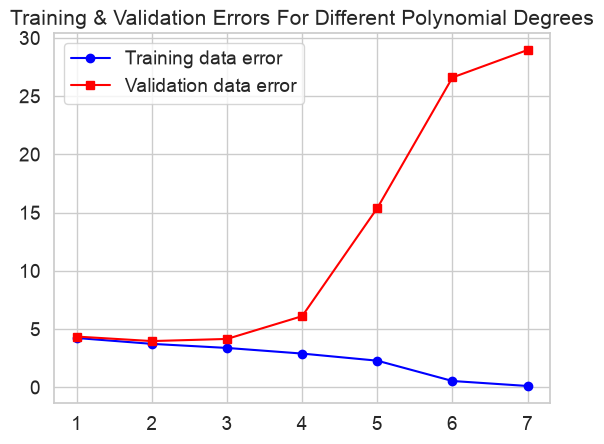

In [50]:
x = [1, 2, 3, 4, 5, 6, 7]
y_tr = []
y_va = []
y_tr.append(err_1[0])
y_tr.append(err_2[0])
y_tr.append(err_3[0])
y_tr.append(err_4[0])
y_tr.append(err_5[0])
y_tr.append(err_6[0])
y_tr.append(err_7[0])

y_va.append(err_1[1])
y_va.append(err_2[1])
y_va.append(err_3[1])
y_va.append(err_4[1])
y_va.append(err_5[1])
y_va.append(err_6[1])
y_va.append(err_7[1])

plt.plot(x, y_tr, label="Training data error", color="blue", marker="o")
plt.plot(x, y_va, label="Validation data error", color="red", marker="s")
plt.title("Training & Validation Errors For Different Polynomial Degrees")
plt.legend()
print(x)


In [51]:
alpha_list = np.asarray([1.e-10, 1.e-08, 1.e-06, 1.e-04, 1.e-02, 1.e+00, 1.e+02, 1.e+04, 1.e+06])

In [52]:
# Problem 2B
# alpha 0

y_tr = []
y_va = []

ridge_alpha_pipeline_0 = sklearn.pipeline.Pipeline([
    ("preproc", sklearn.preprocessing.PolynomialFeatures(degree=4, include_bias=False)),
    ('rescaler', sklearn.preprocessing.MinMaxScaler()),
    ("regr", sklearn.linear_model.Ridge(alpha=alpha_list[0])),
])

ridge_alpha_pipeline_0.fit(x_tr_MF, y_tr_M)
y_0_tr = ridge_alpha_pipeline_0.predict(x_tr_MF)
y_0_va = ridge_alpha_pipeline_0.predict(x_va_NF)

y_0_tr = sanitize(y_0_tr)
y_0_va = sanitize(y_0_va)

y_tr.append(sklearn.metrics.root_mean_squared_error(y_tr_M, y_0_tr))
y_va.append(sklearn.metrics.root_mean_squared_error(y_va_N, y_0_va))

print(y_tr)
print(y_va)



[2.9051438921469384]
[6.075576920592238]


In [53]:
# alpha 1
ridge_alpha_pipeline_1 = sklearn.pipeline.Pipeline([
    ("preproc", sklearn.preprocessing.PolynomialFeatures(degree=4, include_bias=False)),
    ('rescaler', sklearn.preprocessing.MinMaxScaler()),
    ("regr", sklearn.linear_model.Ridge(alpha=alpha_list[1])),
])

ridge_alpha_pipeline_1.fit(x_tr_MF, y_tr_M)
y_1_tr = ridge_alpha_pipeline_1.predict(x_tr_MF)
y_1_va = ridge_alpha_pipeline_1.predict(x_va_NF)

y_1_tr = sanitize(y_1_tr)
y_1_va = sanitize(y_1_va)

y_tr.append(sklearn.metrics.root_mean_squared_error(y_tr_M, y_1_tr))
y_va.append(sklearn.metrics.root_mean_squared_error(y_va_N, y_1_va))

print(y_tr)
print(y_va)

[2.9051438921469384, 2.9863316244151883]
[6.075576920592238, 4.654165636768943]


In [54]:
# alpha 2
ridge_alpha_pipeline_2 = sklearn.pipeline.Pipeline([
    ("preproc", sklearn.preprocessing.PolynomialFeatures(degree=4, include_bias=False)),
    ('rescaler', sklearn.preprocessing.MinMaxScaler()),
    ("regr", sklearn.linear_model.Ridge(alpha=alpha_list[2])),
])

ridge_alpha_pipeline_2.fit(x_tr_MF, y_tr_M)
y_2_tr = ridge_alpha_pipeline_2.predict(x_tr_MF)
y_2_va = ridge_alpha_pipeline_2.predict(x_va_NF)

y_2_tr = sanitize(y_2_tr)
y_2_va = sanitize(y_2_va)

y_tr.append(sklearn.metrics.root_mean_squared_error(y_tr_M, y_2_tr))
y_va.append(sklearn.metrics.root_mean_squared_error(y_va_N, y_2_va))

print(y_tr)
print(y_va)

[2.9051438921469384, 2.9863316244151883, 3.2116459657192533]
[6.075576920592238, 4.654165636768943, 4.138151676951054]


In [55]:
# alpha 3
ridge_alpha_pipeline_3 = sklearn.pipeline.Pipeline([
    ("preproc", sklearn.preprocessing.PolynomialFeatures(degree=4, include_bias=False)),
    ('rescaler', sklearn.preprocessing.MinMaxScaler()),
    ("regr", sklearn.linear_model.Ridge(alpha=alpha_list[3])),
])

ridge_alpha_pipeline_3.fit(x_tr_MF, y_tr_M)
y_3_tr = ridge_alpha_pipeline_3.predict(x_tr_MF)
y_3_va = ridge_alpha_pipeline_3.predict(x_va_NF)

y_3_tr = sanitize(y_3_tr)
y_3_va = sanitize(y_3_va)

y_tr.append(sklearn.metrics.root_mean_squared_error(y_tr_M, y_3_tr))
y_va.append(sklearn.metrics.root_mean_squared_error(y_va_N, y_3_va))

print(y_tr)
print(y_va)

[2.9051438921469384, 2.9863316244151883, 3.2116459657192533, 3.4602062195849164]
[6.075576920592238, 4.654165636768943, 4.138151676951054, 3.9261515899801225]


In [56]:
# alpha 4
ridge_alpha_pipeline_4 = sklearn.pipeline.Pipeline([
    ("preproc", sklearn.preprocessing.PolynomialFeatures(degree=4, include_bias=False)),
    ('rescaler', sklearn.preprocessing.MinMaxScaler()),
    ("regr", sklearn.linear_model.Ridge(alpha=alpha_list[4])),
])

ridge_alpha_pipeline_4.fit(x_tr_MF, y_tr_M)
y_4_tr = ridge_alpha_pipeline_4.predict(x_tr_MF)
y_4_va = ridge_alpha_pipeline_4.predict(x_va_NF)

y_4_tr = sanitize(y_4_tr)
y_4_va = sanitize(y_4_va)

y_tr.append(sklearn.metrics.root_mean_squared_error(y_tr_M, y_4_tr))
y_va.append(sklearn.metrics.root_mean_squared_error(y_va_N, y_4_va))

print(y_tr)
print(y_va)

[2.9051438921469384, 2.9863316244151883, 3.2116459657192533, 3.4602062195849164, 3.6890642965330795]
[6.075576920592238, 4.654165636768943, 4.138151676951054, 3.9261515899801225, 3.9919127603601057]


In [57]:
# alpha 5
ridge_alpha_pipeline_5 = sklearn.pipeline.Pipeline([
    ("preproc", sklearn.preprocessing.PolynomialFeatures(degree=4, include_bias=False)),
    ('rescaler', sklearn.preprocessing.MinMaxScaler()),
    ("regr", sklearn.linear_model.Ridge(alpha=alpha_list[5])),
])

ridge_alpha_pipeline_5.fit(x_tr_MF, y_tr_M)
y_5_tr = ridge_alpha_pipeline_5.predict(x_tr_MF)
y_5_va = ridge_alpha_pipeline_5.predict(x_va_NF)

y_5_tr = sanitize(y_5_tr)
y_5_va = sanitize(y_5_va)

y_tr.append(sklearn.metrics.root_mean_squared_error(y_tr_M, y_5_tr))
y_va.append(sklearn.metrics.root_mean_squared_error(y_va_N, y_5_va))


print(y_tr)
print(y_va)

[2.9051438921469384, 2.9863316244151883, 3.2116459657192533, 3.4602062195849164, 3.6890642965330795, 3.902376777749826]
[6.075576920592238, 4.654165636768943, 4.138151676951054, 3.9261515899801225, 3.9919127603601057, 3.9984535969363386]


In [58]:
# alpha 6
ridge_alpha_pipeline_6 = sklearn.pipeline.Pipeline([
    ("preproc", sklearn.preprocessing.PolynomialFeatures(degree=4, include_bias=False)),
    ('rescaler', sklearn.preprocessing.MinMaxScaler()),
    ("regr", sklearn.linear_model.Ridge(alpha=alpha_list[6])),
])

ridge_alpha_pipeline_6.fit(x_tr_MF, y_tr_M)
y_6_tr = ridge_alpha_pipeline_6.predict(x_tr_MF)
y_6_va = ridge_alpha_pipeline_6.predict(x_va_NF)

y_6_tr = sanitize(y_6_tr)
y_6_va = sanitize(y_6_va)

y_tr.append(sklearn.metrics.root_mean_squared_error(y_tr_M, y_6_tr))
y_va.append(sklearn.metrics.root_mean_squared_error(y_va_N, y_6_va))

print(y_tr)
print(y_va)

[2.9051438921469384, 2.9863316244151883, 3.2116459657192533, 3.4602062195849164, 3.6890642965330795, 3.902376777749826, 5.002073943573182]
[6.075576920592238, 4.654165636768943, 4.138151676951054, 3.9261515899801225, 3.9919127603601057, 3.9984535969363386, 5.0394432633007575]


In [59]:
# alpha 7
ridge_alpha_pipeline_7 = sklearn.pipeline.Pipeline([
    ("preproc", sklearn.preprocessing.PolynomialFeatures(degree=4, include_bias=False)),
    ('rescaler', sklearn.preprocessing.MinMaxScaler()),
    ("regr", sklearn.linear_model.Ridge(alpha=alpha_list[7])),
])

ridge_alpha_pipeline_7.fit(x_tr_MF, y_tr_M)
y_7_tr = ridge_alpha_pipeline_7.predict(x_tr_MF)
y_7_va = ridge_alpha_pipeline_7.predict(x_va_NF)

y_7_tr = sanitize(y_7_tr)
y_7_va = sanitize(y_7_va)

y_tr.append(sklearn.metrics.root_mean_squared_error(y_tr_M, y_7_tr))
y_va.append(sklearn.metrics.root_mean_squared_error(y_va_N, y_7_va))

print(y_tr)
print(y_va)

[2.9051438921469384, 2.9863316244151883, 3.2116459657192533, 3.4602062195849164, 3.6890642965330795, 3.902376777749826, 5.002073943573182, 7.850308765279489]
[6.075576920592238, 4.654165636768943, 4.138151676951054, 3.9261515899801225, 3.9919127603601057, 3.9984535969363386, 5.0394432633007575, 7.286707383548634]


In [60]:
# alpha 8
ridge_alpha_pipeline_8 = sklearn.pipeline.Pipeline([
    ("preproc", sklearn.preprocessing.PolynomialFeatures(degree=4, include_bias=False)),
    ('rescaler', sklearn.preprocessing.MinMaxScaler()),
    ("regr", sklearn.linear_model.Ridge(alpha=alpha_list[8])),
])

ridge_alpha_pipeline_8.fit(x_tr_MF, y_tr_M)
y_8_tr = ridge_alpha_pipeline_8.predict(x_tr_MF)
y_8_va = ridge_alpha_pipeline_8.predict(x_va_NF)

y_8_tr = sanitize(y_8_tr)
y_8_va = sanitize(y_8_va)

y_tr.append(sklearn.metrics.root_mean_squared_error(y_tr_M, y_8_tr))
y_va.append(sklearn.metrics.root_mean_squared_error(y_va_N, y_8_va))

print(y_tr)
print(y_va)

[2.9051438921469384, 2.9863316244151883, 3.2116459657192533, 3.4602062195849164, 3.6890642965330795, 3.902376777749826, 5.002073943573182, 7.850308765279489, 8.226894003957646]
[6.075576920592238, 4.654165636768943, 4.138151676951054, 3.9261515899801225, 3.9919127603601057, 3.9984535969363386, 5.0394432633007575, 7.286707383548634, 7.588743650330758]


10.828706346044399

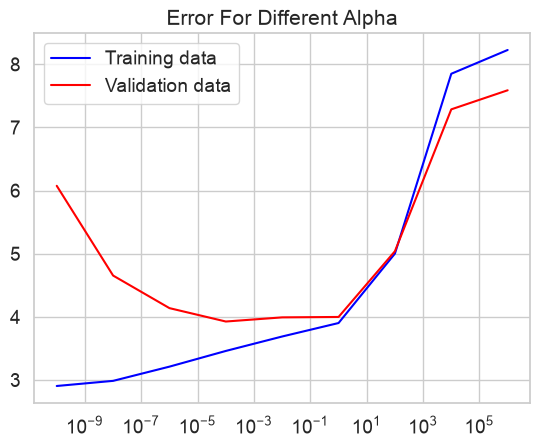

In [61]:
plt.plot(alpha_list, y_tr, label="Training data", color="blue")
plt.plot(alpha_list, y_va, label="Validation data", color="red")
plt.gca().set_xscale('log')
plt.legend()
plt.title("Error For Different Alpha")

# test data
y_5_te = ridge_alpha_pipeline_5.predict(x_te_PF)
sklearn.metrics.root_mean_squared_error(y_va_N, y_5_te)


Provide a brief caption that answers:

Does this plot look as you expect based on course concepts? What specific alpha value do you recommend if we want to "deploy" on new instances and get the lowest possible error?

I think 10^-4 is the best because it has the least validation data error and least overfitting. I expect the graph to look like u-shaped because smaller alpha has less effect on the coefficient so the model would behave similar to unpenalized. The error for validation error is high when alpha is small is because degree 4 is not optimal and shows signs of overfitting. Towards the right, the values of alpha increase logarithmically so the parameters become extreme. Therefore, errors get greater towards right as well. The validation error line concaves up because there are some alphas in between which make the parameters less extreme thus achieving the intended effects.

intercept: -2742.54

   weight   feature var
    42.86 * x0
    -1.32 * x1
  2016.34 * x2
   -13.98 * x3
     0.04 * x0^2
     0.00 * x0 x1
   -21.68 * x0 x2
    -0.17 * x0 x3
    -0.00 * x1^2
     1.14 * x1 x2
    -0.01 * x1 x3
  -483.97 * x2^2
    -2.52 * x2 x3
     0.28 * x3^2
    -0.00 * x0^3
    -0.00 * x0^2 x1
    -0.02 * x0^2 x2
     0.00 * x0^2 x3
     0.00 * x0 x1^2
    -0.01 * x0 x1 x2
     0.00 * x0 x1 x3
     4.72 * x0 x2^2
     0.08 * x0 x2 x3
    -0.00 * x0 x3^2
     0.00 * x1^3
    -0.00 * x1^2 x2
    -0.00 * x1^2 x3
    -0.25 * x1 x2^2
     0.01 * x1 x2 x3
    -0.00 * x1 x3^2
    28.64 * x2^3
     2.48 * x2^2 x3
    -0.14 * x2 x3^2
     0.00 * x3^3
    -0.00 * x0^4
     0.00 * x0^3 x1
     0.00 * x0^3 x2
     0.00 * x0^3 x3
     0.00 * x0^2 x1^2
     0.00 * x0^2 x1 x2
    -0.00 * x0^2 x1 x3
    -0.00 * x0^2 x2^2
     0.00 * x0^2 x2 x3
     0.00 * x0^2 x3^2
    -0.00 * x0 x1^3
     0.00 * x0 x1^2 x2
     0.00 * x0 x1^2 x3
     0.00 * x0 x1 x2^2
    -0.00 * x0 x1 x2 x3
  

/Users/arthur/.local/share/mamba/envs/cs135_26f_env/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 3.434658220966672e-37.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/arthur/.local/share/mamba/envs/cs135_26f_env/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 3.452891509747568e-37.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/arthur/.local/share/mamba/envs/cs135_26f_env/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 5.2761328348766165e-37.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/arthur/.local/share/mamba/envs/cs135_26f_env/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: sli

Text(0.5, 1.0, 'Error For Different Alpha without rescalar')

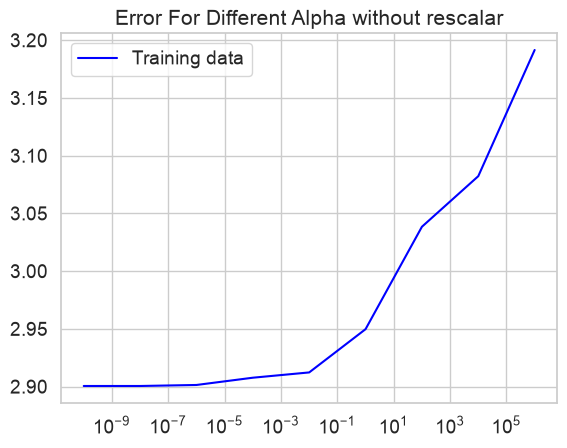

In [62]:
# 2C
# alpha 4
y_tr = []
y_va = []

for i, alpha in enumerate(alpha_list):
    ridge_alpha_pipeline = sklearn.pipeline.Pipeline([
        ("poly_transformer", sklearn.preprocessing.PolynomialFeatures(
            degree=4, include_bias=False
        )),
        ("regr", sklearn.linear_model.Ridge(alpha=alpha)),
    ])

    ridge_alpha_pipeline.fit(x_tr_MF, y_tr_M)

    pred_tr = sanitize(ridge_alpha_pipeline.predict(x_tr_MF))
    pred_va = sanitize(ridge_alpha_pipeline.predict(x_va_NF))

    y_tr.append(
        sklearn.metrics.root_mean_squared_error(y_tr_M, pred_tr)
    )
    y_va.append(
        sklearn.metrics.root_mean_squared_error(y_va_N, pred_va)
    )

    pretty_print_learned_weights(ridge_alpha_pipeline, xcolnames_F=x_tr_MF)



# print("alphas:", alpha_list)
# print("train RMSE:", y_tr)
# print("validation RMSE:", y_va)

# best_i = min(range(len(y_va)), key=y_va.__getitem__)
# print("Best alpha:", alpha_list[best_i])
# print("Best validation RMSE:", y_va[best_i])
plt.plot(alpha_list, y_tr, label="Training data", color="blue")
# plt.plot(alpha_list, y_va, label="Validation data", color="red")
plt.gca().set_xscale('log')
plt.legend()
plt.title("Error For Different Alpha without rescalar")


Try ommiting the rescaling step for the penalized regression model. What happens to training set error when this step is ommited? How do the learned parameters change when the scaling step is omitted? Why might this be the case?

The training set error increased as alpha increases but the range became a lot smaller when the rescaling step is omitted. This could be because the original featured data set is bigger so when it is rescaled to smaller values the coefficients have to be bigger to compensate. Therefore, it results in greater values of errors. The learned parameters also became smaller because the feature data set is bigger so parameters can compensate less and still get similar prediction results.

In [ ]:
# Problem 3
x_trva_LF = np.vstack([x_tr_MF, x_va_NF])
y_trva_L = np.hstack([y_tr_M, y_va_N])

degree_cv_list = [1, 2, 3, 4, 5, 6, 7]
alpha_cv_list = np.logspace(-10, 6, 17)

cv_err = []

kf = sklearn.model_selection.KFold(n_splits=10, shuffle=True, random_state=SEED)
for i, degree in enumerate(degree_cv_list):
    for i, alpha in enumerate(alpha_cv_list):
        fold_err = []

        for train_ind, val_ind in kf.split(x_trva_LF, y_trva_L):
        # ...fit and calculate errors on your model
            x_tr_fold = x_trva_LF[train_ind]
            y_tr_fold = y_trva_L[train_ind]
            x_va_fold = x_trva_LF[val_ind]
            y_va_fold = y_trva_L[val_ind]
    
            model = sklearn.pipeline.Pipeline([
                ("poly_transformer", sklearn.preprocessing.PolynomialFeatures(
                        degree=degree, include_bias=False
                )),
                ('rescaler', sklearn.preprocessing.MinMaxScaler()),
                ("regr", sklearn.linear_model.Ridge(alpha=alpha)),
            ])

            model.fit(x_tr_fold, y_tr_fold)
            trva_err = sanitize(model.predict(x_va_fold)) # validation error
            fold_err.append(
                sklearn.metrics.root_mean_squared_error(y_va_fold, trva_err)
            )
            # print(trva_err)

        cv_err.append({
            "degree": degree,
            "alpha": alpha,
            "rmse": np.mean(fold_err),
        })

minRSME = cv_err[0]["rmse"]
minIndex = 0
for i, val in enumerate(cv_err):
    if minRSME > val["rmse"]:
        minRSME = val["rmse"]
        minIndex = i

print(minIndex)
print(cv_err[minIndex]["alpha"])
print(cv_err[minIndex]["degree"])
print(cv_err[minIndex]["rmse"])

test_model = sklearn.pipeline.Pipeline([
    ("poly_transformer", sklearn.preprocessing.PolynomialFeatures(
            degree=cv_err[minIndex]["degree"], include_bias=False
    )),
    ('rescaler', sklearn.preprocessing.MinMaxScaler()),
    ("regr", sklearn.linear_model.Ridge(alpha=cv_err[minIndex]["alpha"])),
])

test_model.fit(x_trva_LF, y_trva_L)
test_err = sanitize(model.predict(x_te_PF))

test_rmse = sklearn.metrics.root_mean_squared_error(y_te_P, test_err)
print("Test: ", test_rmse)
# 93
# 0.01
# 6
# 3.8815661156475145
# test: 7.105748892546181 (when it is with each fold)

# 102
# alpha: 10^-4
# degree: 7
# 1.9512384177140316
# test: 7.11576037891485 (when it is fited with whole train + val set)
 


    # pipeline.Pipeline([
    #         ("poly_transformer", sklearn.preprocessing.PolynomialFeatures(
    #             degree=4, include_bias=False
    #         )),
    #         ("regr", sklearn.linear_model.Ridge(alpha=alpha)),
    #     ])
    
    #     ridge_alpha_pipeline.fit(x_tr_MF, y_tr_M)
    
    #     pred_tr = sanitize(ridge_alpha_pipeline.predict(x_tr_MF))
    #     pred_va = sanitize(ridge_alpha_pipeline.predict(x_va_NF))
    
    #     y_tr.append(
    #         sklearn.metrics.root_mean_squared_error(y_tr_M, pred_tr)
    #     )
    #     y_va.append(
    #         sklearn.metrics.root_mean_squared_error(y_va_N, pred_va)
    #     )

93
0.01
6
3.8815661156475145
Test:  7.105748892546181


| Model | Hyperparameter value | Test error | Training error | Validation error |
|--------|---:|---:|---:|---:|
| Baseline | Average of Training set | 7.10 | 8.23 | 7.59 |
| Polynomial linear regression | Changing the degree of polynomial | 10.39 | 3.38 |  4.16 |
| Polynomial Ridge regression | fixing degree to 4 and changing alpha | 10.83 |  3.91 |3.99 |
| Polynomial Ridge fold regression | changing degree, alpha to minimize 10-fold cross validation error | 7.11 | 3.88 | 3.88|